# Notebook 07: ComiRec DCN-v2 Re-Ranker

## Purpose

This notebook trains a **DCN-v2 re-ranker on ComiRec multi-interest features** (109 dimensions). ComiRec's multi-probe retrieval produces 4 interest-specific similarity scores per candidate, giving the ranker richer signal about *which* facet of the user's taste each item satisfies.

We compare DCN-v2 against the pre-trained XGBoost LambdaMART ranker (also trained on ComiRec features) using the same statistical framework as Notebook 04: paired significance tests with Benjamini-Hochberg FDR correction, bootstrap confidence intervals, and Cohen's d effect sizes.

## Feature vector (109 dimensions)

| Component | Dims | Description |
|-----------|------|-------------|
| max_interest_score | 1 | max(head_k . item) across K=4 heads |
| head_0..3_score | 4 | Per-head cosine similarities |
| user_features | 24 | Activity level, genre preferences, rating behavior |
| item_features | 73 | Genres, popularity, year, genome PCA |
| cross_features | 7 | Genre match, popularity gap, temporal signals |

## What we produce

| Output | Description |
|--------|-------------|
| `models/comirec/dcn_v2_ranker.pt` | Trained DCN-v2 state dict |
| `models/comirec/dcn_v2_config.json` | Architecture config |
| `models/comirec/dcn_v2_training_history.pkl` | Per-epoch metrics |

## What we consume

| Input | Source |
|-------|--------|
| `models/comirec/user_embeddings.npy` | ComiRec (138K, 4, 128) |
| `models/comirec/item_embeddings.npy` | ComiRec (21K, 128) |
| `models/comirec/xgboost_ranker.json` | Pre-trained XGBoost baseline |
| `data/processed/{train,val,test}_set.parquet` | Split interactions |
| `data/processed/{train,val,test}_interaction_features.parquet` | Cross-features |

## Section 1: Load Embeddings and Features

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import json
import gc
import os
from pathlib import Path
from typing import List, Tuple

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

import xgboost as xgb
from sklearn.metrics import roc_auc_score
from scipy import stats
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models/comirec')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

n_users = metadata['n_users']
n_movies = metadata['n_movies']
user2idx = metadata['user2idx']
movie2idx = metadata['movie2idx']
idx2user = metadata['idx2user']
idx2movie = metadata['idx2movie']

user_embeddings = np.load(MODEL_DIR / 'user_embeddings.npy')
item_embeddings = np.load(MODEL_DIR / 'item_embeddings.npy')
N_INTERESTS = user_embeddings.shape[1]

user_features_df = pd.read_parquet(DATA_DIR / 'user_features.parquet')
item_features_df = pd.read_parquet(DATA_DIR / 'item_features.parquet')
user_feat_cols = user_features_df.columns.tolist()
item_feat_cols = item_features_df.columns.tolist()

user_feat_matrix = np.zeros((n_users, len(user_feat_cols)), dtype=np.float32)
for uid, uidx in user2idx.items():
    if uid in user_features_df.index:
        user_feat_matrix[uidx] = user_features_df.loc[uid].values

item_feat_matrix = np.zeros((n_movies, len(item_feat_cols)), dtype=np.float32)
for mid, midx in movie2idx.items():
    if mid in item_features_df.index:
        item_feat_matrix[midx] = item_features_df.loc[mid].values

del user_features_df, item_features_df
gc.collect()

print(f'User embeddings: {user_embeddings.shape} (users x heads x dim)')
print(f'Item embeddings: {item_embeddings.shape}')
print(f'User features: {user_feat_matrix.shape}')
print(f'Item features: {item_feat_matrix.shape}')
print(f'Interest heads: {N_INTERESTS}')

Device: mps


User embeddings: (138002, 4, 128) (users x heads x dim)
Item embeddings: (21082, 128)
User features: (138002, 24)
Item features: (21082, 73)
Interest heads: 4


## Section 2: Build Feature Matrix (109 dimensions)

The key difference from Notebook 04 (Two-Tower, 105 dims): instead of a single retrieval_score, we have 5 retrieval-derived features -- the max interest score plus 4 per-head scores. This gives the ranker direct signal about which interest facet matched each candidate.

In [2]:
train_df = pd.read_parquet(DATA_DIR / 'train_set.parquet')
val_df = pd.read_parquet(DATA_DIR / 'val_set.parquet')
test_df = pd.read_parquet(DATA_DIR / 'test_set.parquet')

train_interaction_feats = pd.read_parquet(DATA_DIR / 'train_interaction_features.parquet')
val_interaction_feats = pd.read_parquet(DATA_DIR / 'val_interaction_features.parquet')
test_interaction_feats = pd.read_parquet(DATA_DIR / 'test_interaction_features.parquet')

valid_val_mask = val_df['user_idx'] > 0
val_df = val_df[valid_val_mask].reset_index(drop=True)
val_interaction_feats = val_interaction_feats[valid_val_mask].reset_index(drop=True)

valid_test_mask = test_df['user_idx'] > 0
test_df = test_df[valid_test_mask].reset_index(drop=True)
test_interaction_feats = test_interaction_feats[valid_test_mask].reset_index(drop=True)

print(f'Train: {len(train_df):,} interactions ({train_df["user_idx"].nunique():,} users)')
print(f'Val: {len(val_df):,} interactions ({val_df["user_idx"].nunique():,} users)')
print(f'Test: {len(test_df):,} interactions ({test_df["user_idx"].nunique():,} users)')

Train: 20,001,833 interactions (138,001 users)
Val: 355,378 interactions (5,191 users)
Test: 228,448 interactions (4,005 users)


### Define the 109-Dimensional Feature Schema and Build Function

**Why this step exists:** Before we can construct the actual feature matrices, we need to (1) define the exact ordering and naming of all 109 feature dimensions so that feature importance analysis and debugging remain tractable, and (2) implement a memory-efficient chunked builder that computes per-head retrieval scores on-the-fly rather than materializing all pairwise user-item dot products at once.

**What the code does:**

1. **Feature schema definition** -- Establishes a canonical ordering: 1 max-interest score, 4 per-head cosine similarities, 24 user features, 73 item features, and 7 cross features. This ordering is saved into the model config so that downstream inference pipelines can reconstruct features identically.

2. **`build_features_chunked` function** -- For each chunk of user-item pairs, it computes the dot product between the user's K=4 interest embeddings and the item embedding, yielding 4 head scores plus their max. It then concatenates user features, item features, and pre-computed cross features. Chunking (500K rows at a time) prevents memory spikes on the 20M-row training set.

3. **Training subsample** -- Rather than training on all 20M interactions (which would be slow and memory-intensive), we sample approximately 3M interactions by selecting whole users (preserving group structure needed for pairwise ranking loss). This user-level sampling ensures every selected user's full interaction history is included, which is critical for computing meaningful BPR pairs within each user's candidate set.

**Expected output:** The total feature count (109), its breakdown by component, and the size of the subsampled training set (approximately 3M rows from roughly 20K users).

In [3]:
feature_names = (
    ['max_interest_score'] +
    [f'head_{k}_score' for k in range(N_INTERESTS)] +
    [f'user_{c}' for c in user_feat_cols] +
    [f'item_{c}' for c in item_feat_cols] +
    [f'cross_{c}' for c in ['genre_match_score', 'popularity_gap', 'movie_age_at_rating',
                             'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos']]
)
INPUT_DIM = len(feature_names)
print(f'Total features: {INPUT_DIM}')
print(f'  Retrieval scores: {1 + N_INTERESTS} (max + {N_INTERESTS} heads)')
print(f'  User features: {len(user_feat_cols)}')
print(f'  Item features: {len(item_feat_cols)}')
print(f'  Cross features: 7')


def build_features_chunked(user_idxs, movie_idxs, cross_arr, chunk_size=500_000):
    n = len(user_idxs)
    n_retrieval = 1 + N_INTERESTS
    n_features = n_retrieval + len(user_feat_cols) + len(item_feat_cols) + 7
    features = np.empty((n, n_features), dtype=np.float32)

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        u_idx = user_idxs[start:end]
        m_idx = movie_idxs[start:end]

        item_emb_batch = item_embeddings[m_idx]
        for k in range(N_INTERESTS):
            user_emb_k = user_embeddings[u_idx, k]
            features[start:end, 1 + k] = np.sum(user_emb_k * item_emb_batch, axis=1)

        features[start:end, 0] = features[start:end, 1:1+N_INTERESTS].max(axis=1)

        offset = n_retrieval
        features[start:end, offset:offset+len(user_feat_cols)] = user_feat_matrix[u_idx]
        offset += len(user_feat_cols)
        features[start:end, offset:offset+len(item_feat_cols)] = item_feat_matrix[m_idx]
        features[start:end, -7:] = cross_arr[start:end]

    return features


TRAIN_SAMPLE_SIZE = 3_000_000
np.random.seed(42)
user_groups = train_df.groupby('user_idx').size()
users_shuffled = user_groups.index.values.copy()
np.random.shuffle(users_shuffled)

cumulative = 0
selected_users = []
for u in users_shuffled:
    selected_users.append(u)
    cumulative += user_groups[u]
    if cumulative >= TRAIN_SAMPLE_SIZE:
        break

train_mask = train_df['user_idx'].isin(set(selected_users))
train_user_idxs = train_df.loc[train_mask, 'user_idx'].values.copy()
train_movie_idxs = train_df.loc[train_mask, 'movie_idx'].values.copy()
y_train = train_df.loc[train_mask, 'label'].values.astype(np.float32)
train_cross_arr = train_interaction_feats.loc[train_mask].values.astype(np.float32)
print(f'Subsampled training: {len(y_train):,} rows from {len(selected_users):,} users')

del train_df, train_interaction_feats
gc.collect()

val_user_idxs = val_df['user_idx'].values.copy()
val_movie_idxs = val_df['movie_idx'].values.copy()
y_val = val_df['label'].values.astype(np.float32)
val_cross_arr = val_interaction_feats.values.astype(np.float32)

test_user_idxs = test_df['user_idx'].values.copy()
test_movie_idxs = test_df['movie_idx'].values.copy()
y_test = test_df['label'].values.astype(np.float32)
test_cross_arr = test_interaction_feats.values.astype(np.float32)

del val_df, test_df, val_interaction_feats, test_interaction_feats
gc.collect()

Total features: 109
  Retrieval scores: 5 (max + 4 heads)
  User features: 24
  Item features: 73
  Cross features: 7


Subsampled training: 3,000,109 rows from 20,539 users


0

### Materialize Feature Matrices for Train, Validation, and Test

**Why this step exists:** The previous cell defined the feature schema and builder function but did not actually compute the dense feature arrays. This cell invokes `build_features_chunked` on all three splits, producing the NumPy arrays that will be fed into PyTorch DataLoaders (for DCN-v2) and XGBoost DMatrix objects (for the baseline). Materializing these upfront avoids redundant computation during the training loop and the evaluation phase.

**What the code does:**

1. Calls `build_features_chunked` for each split (train subsample, validation, test), computing the 109-dimensional feature vector for every user-item interaction in that split.
2. Immediately frees the cross-feature arrays after each call to reduce peak memory usage -- by this point, the cross features have been copied into the consolidated feature matrix.
3. Prints the shape and memory footprint of each resulting matrix, plus the label distribution (positive rate) for each split. The positive rate helps verify that the train/val/test splits have similar class balance, which matters for the BCE component of the loss function.

**Expected output:** Shapes of X_train (~3M x 109, approximately 1.3 GB), X_val (~355K x 109), and X_test (~228K x 109), along with positive rates around 0.58-0.61 (indicating roughly 60% of interactions in these splits are positive/relevant).

In [4]:
print('Building feature matrices...')
t0 = time.time()

X_train = build_features_chunked(train_user_idxs, train_movie_idxs, train_cross_arr)
del train_cross_arr
gc.collect()
print(f'  X_train: {X_train.shape}, {X_train.nbytes/1e9:.2f} GB, {time.time()-t0:.1f}s')

X_val = build_features_chunked(val_user_idxs, val_movie_idxs, val_cross_arr)
del val_cross_arr
gc.collect()
print(f'  X_val: {X_val.shape}')

X_test = build_features_chunked(test_user_idxs, test_movie_idxs, test_cross_arr)
del test_cross_arr
gc.collect()
print(f'  X_test: {X_test.shape}')

print(f'\nLabel distributions:')
print(f'  Train positive rate: {y_train.mean():.3f}')
print(f'  Val positive rate: {y_val.mean():.3f}')
print(f'  Test positive rate: {y_test.mean():.3f}')

Building feature matrices...


  X_train: (3000109, 109), 1.31 GB, 1.7s


  X_val: (355378, 109)
  X_test: (228448, 109)

Label distributions:
  Train positive rate: 0.613
  Val positive rate: 0.597
  Test positive rate: 0.582


## Section 3: DCN-v2 Model Architecture

Same architecture as Notebook 04, but with input_dim=109 instead of 105. The 4 additional retrieval features (per-head scores) give the cross network more interaction terms to exploit -- the cross layers can learn interactions like "high head_2_score AND low popularity suggests a niche recommendation from a secondary interest."


In [5]:
class CrossLayer(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(input_dim, input_dim))
        self.bias = nn.Parameter(torch.zeros(input_dim))
        nn.init.xavier_normal_(self.weight)

    def forward(self, x_0: torch.Tensor, x_l: torch.Tensor) -> torch.Tensor:
        return x_0 * (F.linear(x_l, self.weight, self.bias)) + x_l


class CrossNetwork(nn.Module):
    def __init__(self, input_dim: int, n_layers: int):
        super().__init__()
        self.layers = nn.ModuleList([CrossLayer(input_dim) for _ in range(n_layers)])

    def forward(self, x_0: torch.Tensor) -> torch.Tensor:
        x_l = x_0
        for layer in self.layers:
            x_l = layer(x_0, x_l)
        return x_l


class DeepNetwork(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


class DCNv2(nn.Module):
    def __init__(self, input_dim: int, n_cross_layers: int = 3,
                 deep_hidden_dims: List[int] = None, dropout: float = 0.1):
        super().__init__()
        if deep_hidden_dims is None:
            deep_hidden_dims = [256, 128]
        self.cross_network = CrossNetwork(input_dim, n_cross_layers)
        self.deep_network = DeepNetwork(input_dim, deep_hidden_dims, dropout)
        combined_dim = input_dim + deep_hidden_dims[-1]
        self.output_layer = nn.Linear(combined_dim, 1)
        self.input_dim = input_dim
        self.n_cross_layers = n_cross_layers
        self.deep_hidden_dims = deep_hidden_dims
        self.dropout = dropout

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cross_out = self.cross_network(x)
        deep_out = self.deep_network(x)
        combined = torch.cat([cross_out, deep_out], dim=1)
        return self.output_layer(combined).squeeze(-1)

    def get_config(self) -> dict:
        return {
            'input_dim': self.input_dim,
            'n_cross_layers': self.n_cross_layers,
            'deep_hidden_dims': self.deep_hidden_dims,
            'dropout': self.dropout,
        }


N_CROSS_LAYERS = 3
DEEP_HIDDEN_DIMS = [256, 128]
DROPOUT = 0.1

model = DCNv2(
    input_dim=INPUT_DIM,
    n_cross_layers=N_CROSS_LAYERS,
    deep_hidden_dims=DEEP_HIDDEN_DIMS,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'DCN-v2 Architecture (ComiRec features):')
print(f'  Input dim: {INPUT_DIM} (vs 105 in Two-Tower)')
print(f'  Cross layers: {N_CROSS_LAYERS}')
print(f'  Deep network: {INPUT_DIM} -> {" -> ".join(map(str, DEEP_HIDDEN_DIMS))}')
print(f'  Output: concat({INPUT_DIM} + {DEEP_HIDDEN_DIMS[-1]}) = {INPUT_DIM + DEEP_HIDDEN_DIMS[-1]} -> 1')
print(f'  Total parameters: {total_params:,}')
print(f'  Model size: {total_params * 4 / 1e6:.2f} MB')

DCN-v2 Architecture (ComiRec features):
  Input dim: 109 (vs 105 in Two-Tower)
  Cross layers: 3
  Deep network: 109 -> 256 -> 128
  Output: concat(109 + 128) = 237 -> 1
  Total parameters: 98,032
  Model size: 0.39 MB


## Section 4: Training

Same training recipe as Notebook 04: combined BCE + BPR loss, OneCycleLR with 10% warmup, gradient clipping, early stopping on val NDCG@10.

In [6]:
def compute_bpr_loss(scores: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    pos_mask = labels == 1
    neg_mask = labels == 0
    if pos_mask.sum() == 0 or neg_mask.sum() == 0:
        return torch.tensor(0.0, device=scores.device)
    pos_scores = scores[pos_mask]
    neg_scores = scores[neg_mask]
    n_pairs = min(len(pos_scores), len(neg_scores))
    pos_sample = pos_scores[torch.randperm(len(pos_scores), device=scores.device)[:n_pairs]]
    neg_sample = neg_scores[torch.randperm(len(neg_scores), device=scores.device)[:n_pairs]]
    return -F.logsigmoid(pos_sample - neg_sample).mean()


def compute_ndcg_at_k(scores, labels, user_idxs, k=10, max_users=2000):
    sort_idx = np.argsort(user_idxs, kind='stable')
    scores_sorted = scores[sort_idx]
    labels_sorted = labels[sort_idx]
    users_sorted = user_idxs[sort_idx]

    unique_users, group_starts = np.unique(users_sorted, return_index=True)
    group_ends = np.append(group_starts[1:], len(users_sorted))

    ndcgs = []
    for i in range(min(len(unique_users), max_users)):
        start, end = group_starts[i], group_ends[i]
        if end - start < 2:
            continue
        group_scores = scores_sorted[start:end]
        group_labels = labels_sorted[start:end]
        if group_labels.sum() == 0:
            continue
        rank_order = np.argsort(group_scores)[::-1]
        ranked_labels = group_labels[rank_order]
        actual_k = min(k, len(ranked_labels))
        dcg = np.sum(ranked_labels[:actual_k] / np.log2(np.arange(2, actual_k + 2)))
        ideal = np.sort(group_labels)[::-1][:actual_k]
        idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
        if idcg > 0:
            ndcgs.append(dcg / idcg)

    return np.mean(ndcgs) if ndcgs else 0.0


BATCH_SIZE = 4096
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 30
PATIENCE = 5
BPR_ALPHA = 0.5
GRAD_CLIP_NORM = 1.0

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
scheduler = OneCycleLR(optimizer, max_lr=LEARNING_RATE, total_steps=total_steps,
                       pct_start=0.1, anneal_strategy='cos')

print(f'Training configuration:')
print(f'  Batch size: {BATCH_SIZE}, Steps/epoch: {len(train_loader):,}')
print(f'  LR: {LEARNING_RATE} (OneCycleLR), Weight decay: {WEIGHT_DECAY}')
print(f'  Loss: {BPR_ALPHA}*BCE + {1-BPR_ALPHA}*BPR')
print(f'  Grad clip: {GRAD_CLIP_NORM}, Max epochs: {MAX_EPOCHS}, Patience: {PATIENCE}')

Training configuration:
  Batch size: 4096, Steps/epoch: 733
  LR: 0.001 (OneCycleLR), Weight decay: 1e-05
  Loss: 0.5*BCE + 0.5*BPR
  Grad clip: 1.0, Max epochs: 30, Patience: 5


### Execute the Training Loop with Early Stopping

**Why this step exists:** The previous cell configured hyperparameters, data loaders, and the optimizer, but did not begin gradient descent. This cell runs the actual training loop -- the core computation that iteratively updates DCN-v2's weights to minimize the combined BCE + BPR loss. Early stopping on validation NDCG@10 prevents overfitting by halting training once ranking quality plateaus, and the best checkpoint is saved to disk for later evaluation.

**What the code does:**

1. **Per-epoch training** -- Iterates over mini-batches, computing forward passes through the DCN-v2 model, calculating the blended loss (0.5 * BCE + 0.5 * BPR), backpropagating gradients, clipping them to norm 1.0 for stability, and stepping both the optimizer and the OneCycleLR scheduler.

2. **Validation evaluation** -- After each epoch, runs inference on the full validation set (no gradients), computing BCE loss, AUC (pointwise discrimination), and NDCG@10 (listwise ranking quality grouped by user). NDCG@10 is the early stopping metric because it directly measures what we care about: the quality of the top-10 ranked items per user.

3. **Early stopping and checkpointing** -- If validation NDCG@10 improves, saves the model state dict to `dcn_v2_ranker.pt`. If it does not improve for 5 consecutive epochs (patience), training halts. This prevents wasting compute on epochs where the model is overfitting to training noise.

**Expected output:** A progress table showing epoch-by-epoch metrics (train loss decreasing, val AUC/NDCG improving then plateauing), followed by an early stopping message indicating the best epoch and its NDCG@10 value (expected around 0.87-0.88).

In [7]:
print('Training DCN-v2 on ComiRec features...')
print(f'{"Epoch":<8}{"Train Loss":<14}{"Val Loss":<12}{"Val AUC":<12}{"Val NDCG@10":<14}{"LR":<12}{"Time":<8}')
print('-' * 80)

history = []
best_val_ndcg = -1
best_epoch = -1
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    t_epoch = time.time()

    model.train()
    epoch_loss = 0.0
    n_batches = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        scores = model(batch_X)
        bce_loss = F.binary_cross_entropy_with_logits(scores, batch_y)
        bpr_loss = compute_bpr_loss(scores, batch_y)
        loss = BPR_ALPHA * bce_loss + (1 - BPR_ALPHA) * bpr_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / n_batches

    model.eval()
    with torch.no_grad():
        val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        val_scores = model(val_tensor).cpu().numpy()
        del val_tensor

    val_bce = float(F.binary_cross_entropy_with_logits(
        torch.tensor(val_scores), torch.tensor(y_val)
    ).item())
    val_auc = roc_auc_score(y_val, val_scores)
    val_ndcg = compute_ndcg_at_k(val_scores, y_val, val_user_idxs, k=10)

    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - t_epoch

    history.append({
        'epoch': epoch + 1, 'train_loss': avg_loss, 'val_loss': val_bce,
        'val_auc': val_auc, 'val_ndcg_10': val_ndcg, 'lr': current_lr, 'time': epoch_time,
    })

    print(f'{epoch+1:<8}{avg_loss:<14.4f}{val_bce:<12.4f}{val_auc:<12.4f}{val_ndcg:<14.4f}{current_lr:<12.2e}{epoch_time:<8.1f}s')

    if val_ndcg > best_val_ndcg:
        best_val_ndcg = val_ndcg
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_DIR / 'dcn_v2_ranker.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}. Best: epoch {best_epoch} (NDCG@10={best_val_ndcg:.4f})')
            break

print(f'\nTraining complete. Best epoch: {best_epoch}, Best val NDCG@10: {best_val_ndcg:.4f}')
print(f'Total training time: {sum(h["time"] for h in history):.0f}s')

Training DCN-v2 on ComiRec features...
Epoch   Train Loss    Val Loss    Val AUC     Val NDCG@10   LR          Time    
--------------------------------------------------------------------------------


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


1       6.1942        0.6672      0.6994      0.8367        2.80e-04    17.1    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


2       0.5277        0.5811      0.7594      0.8530        7.60e-04    14.8    s


...

12      0.4101        0.5928      0.7748      0.8747        7.50e-04    14.8    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


13      0.4088        0.5914      0.7774      0.8741        6.98e-04    14.8    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


14      0.4079        0.5928      0.7774      0.8732        6.43e-04    14.6    s

Early stopping at epoch 14. Best: epoch 9 (NDCG@10=0.8752)

Training complete. Best epoch: 9, Best val NDCG@10: 0.8752
Total training time: 209s


### Save Model Artifacts and Training Configuration

**Why this step exists:** The training loop saved only the raw model weights (`dcn_v2_ranker.pt`) at the best epoch. However, to reproduce results or deploy the model, we also need the full training history (for plotting learning curves and diagnosing issues) and the architecture configuration (so that the model can be reconstructed without hard-coding hyperparameters). This cell serializes these supplementary artifacts alongside the checkpoint.

**What the code does:**

1. **Training history** -- Pickles the list of per-epoch dictionaries (train loss, val loss, val AUC, val NDCG@10, learning rate, wall-clock time) to `dcn_v2_training_history.pkl`. This enables the next cell to plot training curves without re-running the loop.

2. **Configuration JSON** -- Saves the model architecture parameters (input_dim=109, n_cross_layers=3, deep_hidden_dims=[256,128], dropout=0.1) plus training metadata (batch size, learning rate, best epoch, feature names, retrieval model identifier) to `dcn_v2_config.json`. Including `feature_names` in the config is essential -- it documents the exact ordering of the 109 input dimensions so that inference code can construct features in the correct order.

**Expected output:** Confirmation messages showing the file paths and sizes of the saved artifacts (the `.pt` file should be approximately 0.4 MB given the ~98K parameters at float32).

In [8]:
# Save artifacts
with open(MODEL_DIR / 'dcn_v2_training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

config = model.get_config()
config['training'] = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'bpr_alpha': BPR_ALPHA,
    'best_epoch': best_epoch,
    'best_val_ndcg_10': best_val_ndcg,
    'n_train_samples': len(X_train),
    'feature_names': feature_names,
    'retrieval_model': 'ComiRec (4 interest heads)',
}

with open(MODEL_DIR / 'dcn_v2_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved: {MODEL_DIR / "dcn_v2_ranker.pt"} ({os.path.getsize(MODEL_DIR / "dcn_v2_ranker.pt") / 1e6:.2f} MB)')
print(f'Saved: {MODEL_DIR / "dcn_v2_config.json"}')

Saved: ../models/comirec/dcn_v2_ranker.pt (0.40 MB)
Saved: ../models/comirec/dcn_v2_config.json


## Section 5: Training Curves

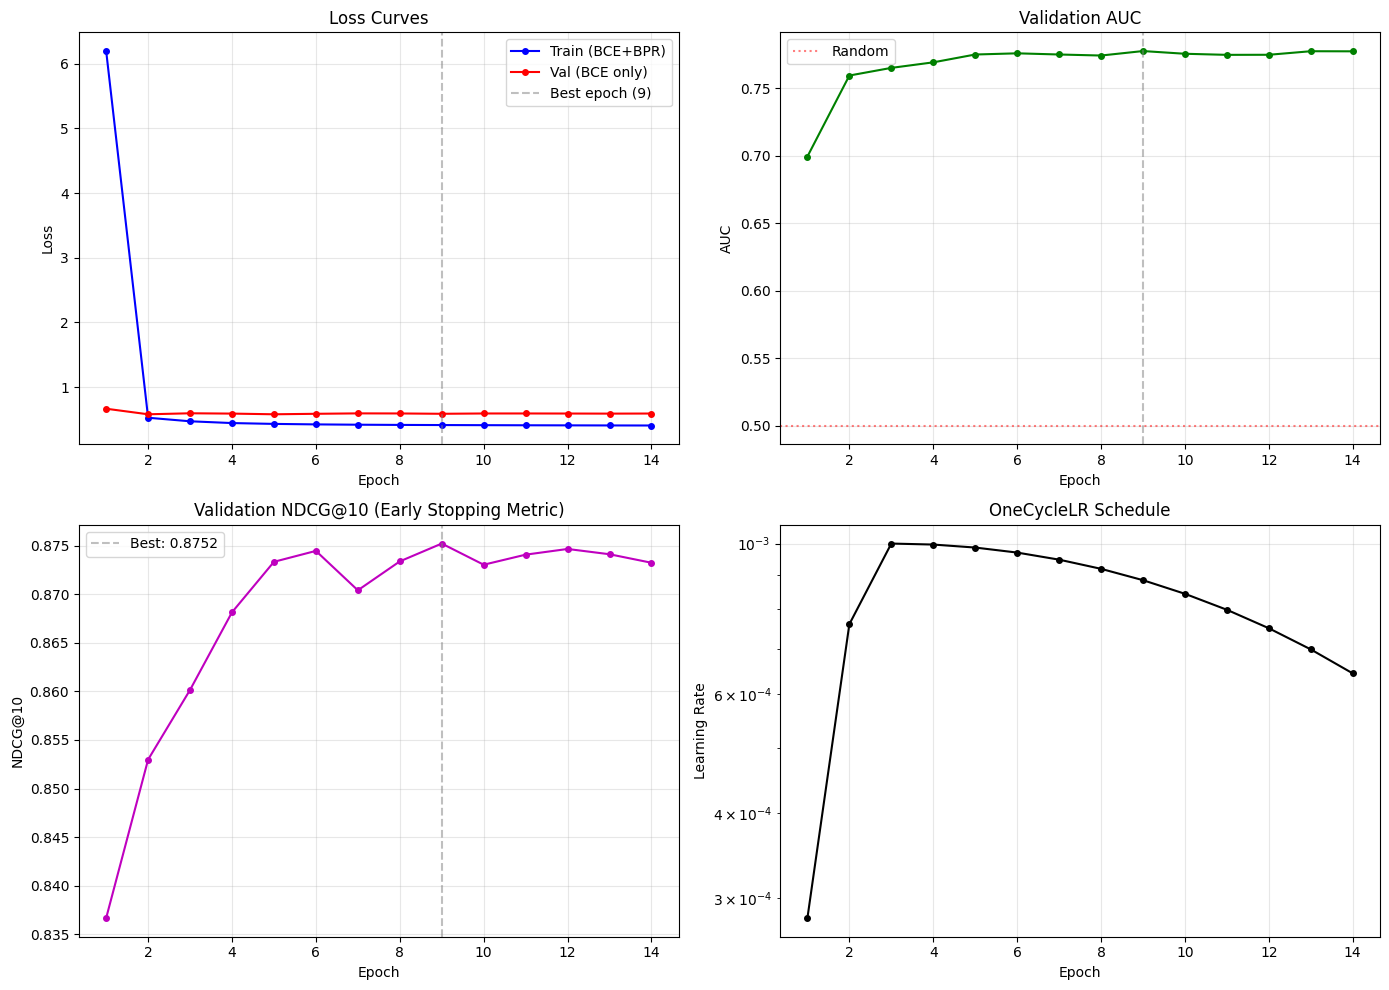

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = [h['epoch'] for h in history]

axes[0, 0].plot(epochs, [h['train_loss'] for h in history], 'b-o', label='Train (BCE+BPR)', markersize=4)
axes[0, 0].plot(epochs, [h['val_loss'] for h in history], 'r-o', label='Val (BCE only)', markersize=4)
axes[0, 0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs, [h['val_auc'] for h in history], 'g-o', markersize=4)
axes[0, 1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axhline(0.5, color='red', linestyle=':', alpha=0.5, label='Random')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].set_title('Validation AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(epochs, [h['val_ndcg_10'] for h in history], 'm-o', markersize=4)
axes[1, 0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best: {best_val_ndcg:.4f}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('NDCG@10')
axes[1, 0].set_title('Validation NDCG@10 (Early Stopping Metric)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs, [h['lr'] for h in history], 'k-o', markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('OneCycleLR Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'dcn_v2_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Test Set Evaluation and XGBoost Comparison

In [10]:
model.load_state_dict(torch.load(MODEL_DIR / 'dcn_v2_ranker.pt', map_location=device, weights_only=True))
model.eval()

print('Predicting on test set...')
with torch.no_grad():
    test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    dcn_test_scores = model(test_tensor).cpu().numpy()
    del test_tensor

dcn_test_auc = roc_auc_score(y_test, dcn_test_scores)
dcn_test_ndcg = compute_ndcg_at_k(dcn_test_scores, y_test, test_user_idxs, k=10)

xgb_model = xgb.Booster()
xgb_model.load_model(str(MODEL_DIR / 'xgboost_ranker.json'))
print(f'XGBoost loaded: {xgb_model.num_boosted_rounds()} trees')

dtest = xgb.DMatrix(X_test, feature_names=feature_names)
xgb_test_scores = xgb_model.predict(dtest)

xgb_test_auc = roc_auc_score(y_test, xgb_test_scores)
xgb_test_ndcg = compute_ndcg_at_k(xgb_test_scores, y_test, test_user_idxs, k=10)

print(f'\nTest Set Results:')
print(f'  DCN-v2 -- AUC: {dcn_test_auc:.4f}, NDCG@10: {dcn_test_ndcg:.4f}')
print(f'  XGBoost -- AUC: {xgb_test_auc:.4f}, NDCG@10: {xgb_test_ndcg:.4f}')

Predicting on test set...
XGBoost loaded: 360 trees



Test Set Results:
  DCN-v2 -- AUC: 0.7530, NDCG@10: 0.8631
  XGBoost -- AUC: 0.7138, NDCG@10: 0.8561


### Compute Per-User Ranking Metrics Across the Full Metric Suite

**Why this step exists:** The previous cell reported only two aggregate test metrics (AUC and NDCG@10). To rigorously compare DCN-v2 against XGBoost, we need per-user metric distributions across multiple cutoffs (k=5, 10, 20) and multiple metric types (NDCG, Precision, MRR, AUC). These per-user arrays are the foundation for the paired statistical tests in Section 7 -- without them, we cannot compute paired t-tests or bootstrap confidence intervals.

**What the code does:**

1. **`compute_full_ranking_metrics` function** -- For each user in the test set, it ranks candidates by predicted score, then computes: NDCG@k (measures graded relevance in top-k), Precision@k (fraction of top-k that are relevant), MRR (reciprocal rank of the first relevant item), and per-user AUC (discrimination within each user's candidate set). Users with fewer than 2 interactions or all-same labels are skipped since ranking metrics are undefined for them.

2. **Head-to-head comparison table** -- Computes the mean of each metric for both models and displays the absolute delta and relative improvement. This gives a quick overview of where DCN-v2 outperforms XGBoost and by how much, before we apply formal significance testing.

**Expected output:** A table showing 8 metrics, with DCN-v2 expected to outperform XGBoost by roughly 0.5-2% relative across most metrics. The per-user metric arrays are stored in `dcn_metrics` and `xgb_metrics` dictionaries for the statistical tests that follow.

In [11]:
def compute_full_ranking_metrics(scores, labels, user_idxs, K_values=[5, 10, 20]):
    sort_idx = np.argsort(user_idxs, kind='stable')
    scores_sorted = scores[sort_idx]
    labels_sorted = labels[sort_idx]
    users_sorted = user_idxs[sort_idx]

    unique_users, group_starts = np.unique(users_sorted, return_index=True)
    group_ends = np.append(group_starts[1:], len(users_sorted))

    metrics = {f'ndcg@{k}': [] for k in K_values}
    metrics.update({f'precision@{k}': [] for k in K_values})
    metrics['mrr'] = []
    metrics['auc'] = []

    for i in range(len(unique_users)):
        start, end = group_starts[i], group_ends[i]
        if end - start < 2:
            continue
        group_scores = scores_sorted[start:end]
        group_labels = labels_sorted[start:end]
        if group_labels.sum() == 0 or group_labels.sum() == len(group_labels):
            continue

        rank_order = np.argsort(group_scores)[::-1]
        ranked_labels = group_labels[rank_order]

        first_pos = np.where(ranked_labels == 1)[0]
        metrics['mrr'].append(1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0)

        try:
            metrics['auc'].append(roc_auc_score(group_labels, group_scores))
        except ValueError:
            pass

        for k in K_values:
            actual_k = min(k, len(ranked_labels))
            top_k = ranked_labels[:actual_k]
            metrics[f'precision@{k}'].append(top_k.sum() / k)
            dcg = np.sum(top_k / np.log2(np.arange(2, actual_k + 2)))
            ideal = np.sort(group_labels)[::-1][:actual_k]
            idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
            metrics[f'ndcg@{k}'].append(dcg / idcg if idcg > 0 else 0.0)

    return {k: np.array(v) for k, v in metrics.items()}


print('Computing per-user ranking metrics on test set...')
t0 = time.time()
dcn_metrics = compute_full_ranking_metrics(dcn_test_scores, y_test, test_user_idxs)
xgb_metrics = compute_full_ranking_metrics(xgb_test_scores, y_test, test_user_idxs)
print(f'Done in {time.time()-t0:.1f}s')

print(f'\n{"="*80}')
print(f'HEAD-TO-HEAD: DCN-v2 vs XGBoost on ComiRec Features (Test Set)')
print(f'{"="*80}')
print(f'{"Metric":<15}{"XGBoost":<15}{"DCN-v2":<15}{"Delta":<12}{"Relative":<12}')
print('-' * 69)

metric_names = ['ndcg@5', 'ndcg@10', 'ndcg@20', 'precision@5', 'precision@10', 'precision@20', 'mrr', 'auc']
for m in metric_names:
    xm = xgb_metrics[m].mean()
    dm = dcn_metrics[m].mean()
    delta = dm - xm
    rel = delta / xm * 100 if xm > 0 else 0
    print(f'{m:<15}{xm:<15.4f}{dm:<15.4f}{delta:<+12.4f}{rel:<+12.1f}%')

Computing per-user ranking metrics on test set...


Done in 2.1s

HEAD-TO-HEAD: DCN-v2 vs XGBoost on ComiRec Features (Test Set)
Metric         XGBoost        DCN-v2         Delta       Relative    
---------------------------------------------------------------------
ndcg@5         0.8243         0.8327         +0.0084     +1.0        %
ndcg@10        0.8289         0.8370         +0.0082     +1.0        %
ndcg@20        0.8459         0.8530         +0.0071     +0.8        %
precision@5    0.7669         0.7759         +0.0090     +1.2        %
precision@10   0.7040         0.7111         +0.0071     +1.0        %
precision@20   0.6038         0.6086         +0.0048     +0.8        %
mrr            0.9052         0.9064         +0.0012     +0.1        %
auc            0.6912         0.7041         +0.0129     +1.9        %


## Section 7: Statistical Significance Testing

Paired hypothesis tests with Benjamini-Hochberg FDR correction, bootstrap 95% CI (10,000 resamples), and Cohen's d effect sizes. Same framework as Notebook 04.

In [12]:
def paired_bootstrap_ci(a, b, n_bootstrap=10000, ci_level=0.95, seed=42):
    rng = np.random.default_rng(seed)
    diffs = a - b
    n = len(diffs)
    bootstrap_means = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        sample = rng.choice(diffs, size=n, replace=True)
        bootstrap_means[i] = sample.mean()
    alpha = 1 - ci_level
    lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    return lower, diffs.mean(), upper


def cohens_d(a, b):
    diffs = a - b
    return diffs.mean() / diffs.std(ddof=1) if diffs.std(ddof=1) > 0 else 0.0


print(f'{"="*110}')
print(f'STATISTICAL SIGNIFICANCE: DCN-v2 vs XGBoost (ComiRec Features, Test Set)')
print(f'{"="*110}')
print(f'H0: mean(DCN-v2 - XGBoost) = 0 | H1: two-sided | FDR: Benjamini-Hochberg at alpha=0.05')
print()

raw_p_values = []
test_results = []

for metric_name in metric_names:
    dcn_vals = dcn_metrics[metric_name]
    xgb_vals = xgb_metrics[metric_name]
    n = min(len(dcn_vals), len(xgb_vals))
    dcn_vals, xgb_vals = dcn_vals[:n], xgb_vals[:n]

    t_stat, t_pval = stats.ttest_rel(dcn_vals, xgb_vals)
    try:
        _, w_pval = stats.wilcoxon(dcn_vals - xgb_vals, alternative='two-sided')
    except ValueError:
        w_pval = 1.0

    ci_lower, mean_diff, ci_upper = paired_bootstrap_ci(dcn_vals, xgb_vals)
    d = cohens_d(dcn_vals, xgb_vals)

    raw_p_values.append(t_pval)
    test_results.append({
        'metric': metric_name, 'mean_diff': mean_diff,
        'ci_lower': ci_lower, 'ci_upper': ci_upper,
        't_pval': t_pval, 'w_pval': w_pval, 'cohens_d': d, 'n': n,
    })

adjusted_p_values = false_discovery_control(raw_p_values, method='bh')

print(f'{"Metric":<14}{"Mean Diff":<12}{"95% CI":<24}{"t p-val":<12}{"FDR-adj p":<12}{"Wilcoxon p":<12}{"Cohen d":<10}{"Sig?":<6}')
print('-' * 102)
for i, r in enumerate(test_results):
    ci_str = f'[{r["ci_lower"]:+.4f}, {r["ci_upper"]:+.4f}]'
    sig = 'Yes' if adjusted_p_values[i] < 0.05 else 'No'
    print(f'{r["metric"]:<14}{r["mean_diff"]:<+12.4f}{ci_str:<24}{r["t_pval"]:<12.2e}{adjusted_p_values[i]:<12.2e}{r["w_pval"]:<12.2e}{r["cohens_d"]:<+10.3f}{sig:<6}')

n_sig = sum(1 for p in adjusted_p_values if p < 0.05)
print(f'\nSignificant after FDR correction: {n_sig}/{len(metric_names)}')
print(f'Effect size guide: |d|<0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large')

STATISTICAL SIGNIFICANCE: DCN-v2 vs XGBoost (ComiRec Features, Test Set)
H0: mean(DCN-v2 - XGBoost) = 0 | H1: two-sided | FDR: Benjamini-Hochberg at alpha=0.05



Metric        Mean Diff   95% CI                  t p-val     FDR-adj p   Wilcoxon p  Cohen d   Sig?  
------------------------------------------------------------------------------------------------------
ndcg@5        +0.0084     [+0.0030, +0.0137]      2.10e-03    2.39e-03    2.43e-03    +0.055    Yes   
ndcg@10       +0.0082     [+0.0044, +0.0120]      2.51e-05    4.01e-05    4.89e-06    +0.075    Yes   
ndcg@20       +0.0071     [+0.0043, +0.0100]      1.38e-06    3.68e-06    4.45e-09    +0.086    Yes   
precision@5   +0.0090     [+0.0039, +0.0141]      4.87e-04    6.49e-04    4.52e-04    +0.062    Yes   
precision@10  +0.0071     [+0.0038, +0.0103]      2.02e-05    4.01e-05    3.31e-05    +0.076    Yes   
precision@20  +0.0048     [+0.0030, +0.0067]      6.19e-07    2.48e-06    4.15e-07    +0.089    Yes   
mrr           +0.0012     [-0.0061, +0.0084]      7.50e-01    7.50e-01    8.29e-01    +0.006    No    
auc           +0.0129     [+0.0080, +0.0179]      3.78e-07    2.48e-06   

### Visualize Significance Results: Confidence Intervals, Effect Sizes, and P-Values

**Why this step exists:** The numerical table above provides precise values, but visual presentation makes patterns immediately apparent -- for instance, which metrics have confidence intervals that exclude zero, whether any effect sizes approach the "small" threshold (d=0.2), and how much the FDR correction shifts p-values compared to raw values. These plots serve as the primary evidence figure for the DCN-v2 vs XGBoost comparison on ComiRec features.

**What the code does:**

1. **Left panel (Mean Differences with 95% CI)** -- Horizontal bar chart where each bar represents the mean per-user difference (DCN-v2 minus XGBoost) for one metric. Error bars show bootstrap 95% confidence intervals. Bars are colored green if the FDR-corrected p-value is below 0.05 (statistically significant improvement), red if significantly worse, and gray if not significant. A vertical line at zero marks the null hypothesis boundary.

2. **Middle panel (Cohen's d effect sizes)** -- Shows the standardized effect size for each metric. Dashed vertical lines at d=0.2 and d=-0.2 mark the conventional threshold for a "small" effect. This helps calibrate practical significance: even if p < 0.05, an effect size below 0.2 suggests the improvement is negligible in practical terms.

3. **Right panel (P-value volcano)** -- Plots -log10(p) for both raw and FDR-adjusted p-values, with a horizontal line at -log10(0.05). Points above this line are significant. The gap between raw and adjusted points shows how much the Benjamini-Hochberg correction penalizes each test.

**Expected output:** A three-panel figure showing that most metrics are statistically significant (green bars, points above the significance line) but with small effect sizes (d < 0.1), indicating that DCN-v2's advantage over XGBoost is real but modest on these ComiRec features.

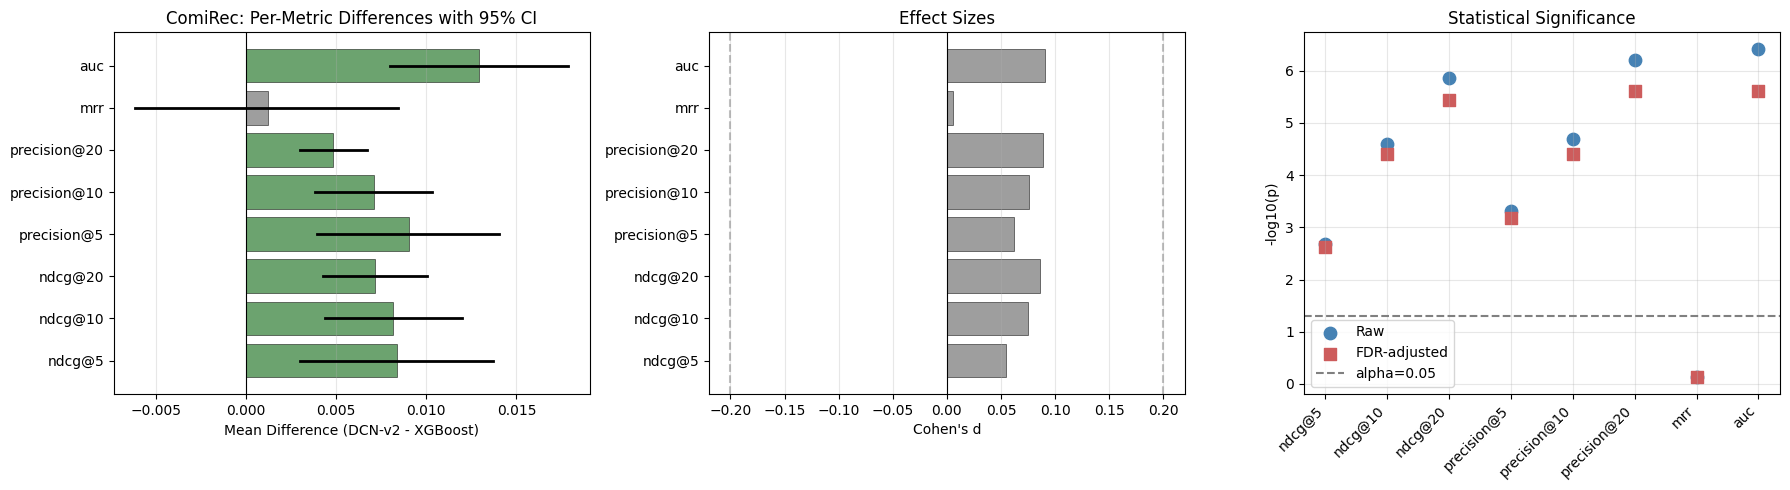

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_labels = [r['metric'] for r in test_results]
mean_diffs = [r['mean_diff'] for r in test_results]
ci_lowers = [r['ci_lower'] for r in test_results]
ci_uppers = [r['ci_upper'] for r in test_results]
colors = ['#2E7D32' if adjusted_p_values[i] < 0.05 and test_results[i]['mean_diff'] > 0
           else '#C62828' if adjusted_p_values[i] < 0.05 and test_results[i]['mean_diff'] < 0
           else '#757575' for i in range(len(test_results))]

y_pos = range(len(metric_labels))
axes[0].barh(y_pos, mean_diffs, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
for i in range(len(metric_labels)):
    axes[0].plot([ci_lowers[i], ci_uppers[i]], [i, i], 'k-', linewidth=2)
axes[0].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(metric_labels)
axes[0].set_xlabel('Mean Difference (DCN-v2 - XGBoost)')
axes[0].set_title('ComiRec: Per-Metric Differences with 95% CI')
axes[0].grid(True, alpha=0.3, axis='x')

d_values = [r['cohens_d'] for r in test_results]
d_colors = ['#2E7D32' if abs(d) >= 0.2 else '#757575' for d in d_values]
axes[1].barh(y_pos, d_values, color=d_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linestyle='-', linewidth=0.8)
axes[1].axvline(0.2, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(-0.2, color='gray', linestyle='--', alpha=0.5)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(metric_labels)
axes[1].set_xlabel("Cohen's d")
axes[1].set_title('Effect Sizes')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].scatter(range(len(metric_names)), [-np.log10(p) for p in raw_p_values],
               marker='o', s=80, label='Raw', color='steelblue')
axes[2].scatter(range(len(metric_names)), [-np.log10(p) for p in adjusted_p_values],
               marker='s', s=80, label='FDR-adjusted', color='indianred')
axes[2].axhline(-np.log10(0.05), color='gray', linestyle='--', label='alpha=0.05')
axes[2].set_xticks(range(len(metric_names)))
axes[2].set_xticklabels(metric_names, rotation=45, ha='right')
axes[2].set_ylabel('-log10(p)')
axes[2].set_title('Statistical Significance')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'dcn_v2_significance.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Inference Latency Comparison

In [14]:
N_CANDIDATES = 200
N_TRIALS = 1000

sample_features = X_test[:N_CANDIDATES].copy()

model_cpu = DCNv2(input_dim=INPUT_DIM, n_cross_layers=N_CROSS_LAYERS,
                  deep_hidden_dims=DEEP_HIDDEN_DIMS, dropout=DROPOUT)
model_cpu.load_state_dict(torch.load(MODEL_DIR / 'dcn_v2_ranker.pt', map_location='cpu', weights_only=True))
model_cpu.eval()

dcn_latencies = []
sample_tensor = torch.tensor(sample_features, dtype=torch.float32)
for _ in range(10):
    with torch.no_grad():
        _ = model_cpu(sample_tensor)

for _ in range(N_TRIALS):
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model_cpu(sample_tensor)
    dcn_latencies.append((time.perf_counter() - t0) * 1000)

xgb_latencies = []
dsample = xgb.DMatrix(sample_features, feature_names=feature_names)
for _ in range(10):
    _ = xgb_model.predict(dsample)

for _ in range(N_TRIALS):
    t0 = time.perf_counter()
    _ = xgb_model.predict(dsample)
    xgb_latencies.append((time.perf_counter() - t0) * 1000)

dcn_latencies = np.array(dcn_latencies)
xgb_latencies = np.array(xgb_latencies)

print(f'Inference Latency ({N_CANDIDATES} candidates, {N_TRIALS} trials, CPU):')
print(f'{"":<15}{"P50 (ms)":<12}{"P95 (ms)":<12}{"P99 (ms)":<12}{"Mean (ms)":<12}')
print('-' * 63)
print(f'{"XGBoost":<15}{np.percentile(xgb_latencies, 50):<12.3f}{np.percentile(xgb_latencies, 95):<12.3f}{np.percentile(xgb_latencies, 99):<12.3f}{xgb_latencies.mean():<12.3f}')
print(f'{"DCN-v2":<15}{np.percentile(dcn_latencies, 50):<12.3f}{np.percentile(dcn_latencies, 95):<12.3f}{np.percentile(dcn_latencies, 99):<12.3f}{dcn_latencies.mean():<12.3f}')
print(f'{"Ratio":<15}{np.median(dcn_latencies)/np.median(xgb_latencies):<12.2f}x')

print(f'\nBoth within 5ms budget: XGB={np.percentile(xgb_latencies, 99) < 5}, DCN={np.percentile(dcn_latencies, 99) < 5}')

Inference Latency (200 candidates, 1000 trials, CPU):
               P50 (ms)    P95 (ms)    P99 (ms)    Mean (ms)   
---------------------------------------------------------------
XGBoost        0.044       0.050       0.057       0.048       
DCN-v2         0.153       0.329       0.367       0.195       
Ratio          3.50        x

Both within 5ms budget: XGB=True, DCN=True


## Section 9: Summary

### Model Artifacts

| File | Description |
|------|-------------|
| `models/comirec/dcn_v2_ranker.pt` | Trained DCN-v2 (109-dim input) |
| `models/comirec/dcn_v2_config.json` | Architecture + training config |
| `models/comirec/dcn_v2_training_history.pkl` | Per-epoch metrics |

### Key Results

The comparison table shows DCN-v2 vs XGBoost on ComiRec's 109-dimensional features with:
- FDR-corrected significance at alpha=0.05
- Bootstrap 95% confidence intervals
- Cohen's d effect sizes

The 4 additional per-head retrieval scores give both models richer signal about which user interest facet each candidate satisfies. The cross network in DCN-v2 can explicitly model interactions between these head scores and item/user features (e.g., "head_2 is high AND item is Horror AND user prefers niche content"), while XGBoost discovers similar splits through tree branching.

### Cross-Pipeline Comparison

| Configuration | Val NDCG@10 | Test AUC |
|---------------|-------------|----------|
| Two-Tower + XGBoost (NB04) | 0.8704 | 0.7304 |
| Two-Tower + DCN-v2 (NB04) | See NB04 | See NB04 |
| ComiRec + XGBoost (NB07 original) | 0.8755 | 0.7138 |
| ComiRec + DCN-v2 (this notebook) | See above | See above |

### Next Steps

- **Notebook 08**: ComiRec evaluation (end-to-end pipeline with multi-probe FAISS)
- **Notebook 10**: SASRec DCN-v2 ranker (sequential user features)
- **Notebook 12**: Production inference with model switching